In [ ]:
# =========================================================
# FIX NUMPY FIRST
# =========================================================

!pip install -q "numpy==1.26.4"

# =========================================================
# INSTALL ONLY MISSING / REQUIRED PACKAGES
# =========================================================

!pip install -q \
    Pillow==9.5.0 \
    timm \
    facenet-pytorch \
    albumentations \
    optuna \
    torchmetrics \
    pyyaml

# =========================================================
# IMPORTANT:
# AFTER THIS CELL:
# Runtime -> Restart Session
# THEN RUN ALL CELLS AGAIN
# =========================================================

print("✅ Install complete")
print("⚠️ Now restart the Kaggle session before continuing")

In [1]:
import numpy as np
import torch
import torchvision
import timm
import PIL
import albumentations
import optuna
import torchmetrics
import yaml

print("=" * 50)
print("📦 Package Versions")
print("=" * 50)

print("NumPy       :", np.__version__)
print("PyTorch     :", torch.__version__)
print("Torchvision :", torchvision.__version__)
print("timm        :", timm.__version__)
print("Pillow      :", PIL.__version__)
print("Albumentations:", albumentations.__version__)
print("Optuna      :", optuna.__version__)
print("TorchMetrics:", torchmetrics.__version__)

print("\n✅ Environment ready")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 1082, in launch_instance
    app.start()
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start
    self.io_loop.start()
  File "/usr/local/lib/python3.12/dist-packag

📦 Package Versions
NumPy       : 2.4.6
PyTorch     : 2.2.2+cu121
Torchvision : 0.17.2+cu121
timm        : 1.0.26
Pillow      : 9.5.0
Albumentations: 2.0.8
Optuna      : 4.8.0
TorchMetrics: 1.9.0

✅ Environment ready


In [2]:
!pip uninstall -y numpy
!pip install -q numpy==1.26.4

Found existing installation: numpy 2.4.6
Uninstalling numpy-2.4.6:
  Successfully uninstalled numpy-2.4.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
kaggle-environments 1.29.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
ydata-profiling 4.18.4 requires numba<0.63,>=0.60, but you have numba 0.65.1 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.

In [ ]:
import os
os._exit(00)

In [1]:
import numpy as np
print(np.__version__)

1.26.4


In [2]:
import torch
import torchvision

In [4]:
import os

# Kaggle working directory
BASE     = '/kaggle/working'
UTILS    = f'{BASE}/utils'
CONFIGS  = f'{BASE}/configs'
MODELS   = f'{BASE}/saved_models'
RESULTS  = f'{BASE}/results/plots'
METRICS  = f'{BASE}/results/metrics'
PREDS    = f'{BASE}/results/predictions'
CROPS    = f'{BASE}/face_crops'

for folder in [UTILS, CONFIGS, MODELS, RESULTS, METRICS, PREDS, CROPS]:
    os.makedirs(folder, exist_ok=True)

print("✅ Directory structure created:")
for folder in [UTILS, CONFIGS, MODELS, RESULTS, METRICS, PREDS, CROPS]:
    print(f"   {folder}")

✅ Directory structure created:
   /kaggle/working/utils
   /kaggle/working/configs
   /kaggle/working/saved_models
   /kaggle/working/results/plots
   /kaggle/working/results/metrics
   /kaggle/working/results/predictions
   /kaggle/working/face_crops


In [5]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import yaml
import json
import time
import warnings
import shutil
from pathlib import Path
from tqdm import tqdm
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler

# timm
import timm

# Albumentations
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Sklearn
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr

# Face detection
from facenet_pytorch import MTCNN

# Optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device : {device}")
print(f"   GPU   : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
print(f"   timm  : {timm.__version__}")

✅ Device : cuda
   GPU   : Tesla T4
   timm  : 1.0.26


In [6]:
%%writefile /kaggle/working/configs/model_config.yaml

models:
  efficientnet_b3:
    arch: efficientnet_b3
    img_size: 224
    dropout: 0.4
  efficientnet_b4:
    arch: efficientnet_b4
    img_size: 224
    dropout: 0.4
  resnet50:
    arch: resnet50
    img_size: 224
    dropout: 0.4
  swin_tiny:
    arch: swin_tiny_patch4_window7_224
    img_size: 224
    dropout: 0.4

Writing /kaggle/working/configs/model_config.yaml


In [22]:
%%writefile /kaggle/working/configs/train_config.yaml

training:
  epochs: 30
  batch_size: 32
  lr_head: 1e-3
  lr_backbone: 1e-4
  weight_decay: 1e-4
  patience: 5
  freeze_epochs: 5
  num_workers: 2
  seed: 42

loss:
  type: huber
  delta: 1.0

scheduler:
  type: cosine_warm_restarts
  T_0: 10
  T_mult: 2

oof:
  n_splits: 5

selection:
  mae_weight: 0.6
  r2_weight: 0.4

Writing /kaggle/working/configs/train_config.yaml


In [7]:
%%writefile /kaggle/working/utils/face_detection.py

import os
import cv2
import numpy as np
from PIL import Image
from facenet_pytorch import MTCNN
import torch
from tqdm import tqdm
import pandas as pd

def get_mtcnn(device):
    return MTCNN(
        image_size=224,
        margin=20,
        min_face_size=40,
        thresholds=[0.6, 0.7, 0.7],
        factor=0.709,
        keep_all=False,
        device=device
    )

def crop_and_save_face(img_path, save_path, mtcnn):
    """
    Detect, align and save face crop.
    Returns True if successful, False if no face detected.
    """
    try:
        img = Image.open(img_path).convert('RGB')
        face = mtcnn(img)

        if face is None:
            return False

        # Convert tensor to numpy for saving
        face_np = face.permute(1, 2, 0).numpy()
        face_np = ((face_np - face_np.min()) /
                   (face_np.max() - face_np.min()) * 255).astype(np.uint8)
        face_bgr = cv2.cvtColor(face_np, cv2.COLOR_RGB2BGR)
        cv2.imwrite(save_path, face_bgr)
        return True

    except Exception as e:
        return False


def process_all_faces(df, raw_base, crops_dir, device):
    """
    Run MTCNN on all images, save crops, return clean dataframe.
    """
    mtcnn = get_mtcnn(device)
    
    success, failed = [], []
    records = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Detecting faces"):
        img_path  = row['img_path']
        person_id = row['person_id']
        bmi       = row['bmi']

        # Unique save name per image
        img_name  = os.path.basename(img_path).replace('.jpg', '_crop.jpg')
        save_path = os.path.join(crops_dir, img_name)

        # Skip if already processed
        if os.path.exists(save_path):
            records.append({
                'crop_path': save_path,
                'person_id': person_id,
                'bmi':       bmi
            })
            success.append(img_path)
            continue

        ok = crop_and_save_face(img_path, save_path, mtcnn)

        if ok:
            records.append({
                'crop_path': save_path,
                'person_id': person_id,
                'bmi':       bmi
            })
            success.append(img_path)
        else:
            failed.append(img_path)

    print(f"\n✅ Face detection complete")
    print(f"   Success : {len(success)}")
    print(f"   Failed  : {len(failed)}")
    print(f"   Rate    : {len(success)/len(df)*100:.1f}%")

    if failed:
        pd.DataFrame({'failed_path': failed}).to_csv(
            '/kaggle/working/results/metrics/failed_detections.csv', index=False
        )

    return pd.DataFrame(records)

Writing /kaggle/working/utils/face_detection.py


In [28]:
%%writefile /kaggle/working/utils/dataset.py

import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, WeightedRandomSampler
import albumentations as A
from albumentations.pytorch import ToTensorV2


def get_transforms(img_size=224, mode='train'):
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]

    if mode == 'train':
        return A.Compose([
            A.Resize(img_size, img_size),
            A.HorizontalFlip(p=0.5),
            A.RandomBrightnessContrast(p=0.4),
            A.HueSaturationValue(p=0.3),
            A.ShiftScaleRotate(shift_limit=0.05,
                               scale_limit=0.1,
                               rotate_limit=10, p=0.4),
            A.GaussNoise(p=0.2),
            A.CoarseDropout(max_holes=4, max_height=20,
                            max_width=20, p=0.2),
            A.Normalize(mean=mean, std=std),
            ToTensorV2()
        ])
    else:
        return A.Compose([
            A.Resize(img_size, img_size),
            A.Normalize(mean=mean, std=std),
            ToTensorV2()
        ])


def get_tta_transforms(img_size=224):
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]
    return [
        A.Compose([A.Resize(img_size, img_size),
                   A.Normalize(mean=mean, std=std), ToTensorV2()]),
        A.Compose([A.Resize(img_size, img_size), A.HorizontalFlip(p=1.0),
                   A.Normalize(mean=mean, std=std), ToTensorV2()]),
        A.Compose([A.Resize(img_size, img_size),
                   A.RandomBrightnessContrast(
                       brightness_limit=0.1,
                       contrast_limit=0.1, p=1.0),
                   A.Normalize(mean=mean, std=std), ToTensorV2()]),
    ]


class BMIDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.loc[idx]
        img = cv2.imread(row['crop_path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        bmi = torch.tensor(row['bmi'], dtype=torch.float32)

        if self.transform:
            img = self.transform(image=img)['image']

        return img, bmi


def get_sampler(dataframe):
    bmi    = dataframe['bmi'].values
    bins   = [0, 18.5, 25, 30, 35, 100]
    labels = np.digitize(bmi, bins) - 1
    labels = np.clip(labels, 0, len(bins) - 2)

    class_counts   = np.bincount(labels, minlength=len(bins)-1)
    class_weights  = 1.0 / (class_counts + 1e-6)
    sample_weights = class_weights[labels]

    return WeightedRandomSampler(
        weights     = torch.tensor(sample_weights, dtype=torch.float32),
        num_samples = len(dataframe),
        replacement = True
    )

Overwriting /kaggle/working/utils/dataset.py


In [9]:
%%writefile /kaggle/working/utils/models.py

import torch
import torch.nn as nn
import timm


class BMIModel(nn.Module):
    def __init__(self, arch, dropout=0.4, pretrained=True):
        super(BMIModel, self).__init__()

        self.backbone = timm.create_model(
            arch,
            pretrained=pretrained,
            num_classes=0          # remove classifier
        )

        in_features = self.backbone.num_features

        # Regression head
        self.head = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(128, 1)
        )

    def freeze_backbone(self):
        for param in self.backbone.parameters():
            param.requires_grad = False

    def unfreeze_backbone(self):
        for param in self.backbone.parameters():
            param.requires_grad = True

    def forward(self, x):
        features = self.backbone(x)
        return self.head(features).squeeze(1)


def get_model(arch, dropout=0.4, pretrained=True):
    return BMIModel(arch, dropout, pretrained)


# EMA helper
class ModelEMA:
    def __init__(self, model, decay=0.995):
        import copy
        self.ema   = copy.deepcopy(model)
        self.decay = decay
        self.ema.eval()

    def update(self, model):
        with torch.no_grad():
            for ema_p, p in zip(self.ema.parameters(),
                                model.parameters()):
                ema_p.data.mul_(self.decay).add_(
                    p.data, alpha=1 - self.decay
                )

    def __call__(self, x):
        return self.ema(x)

Writing /kaggle/working/utils/models.py


In [34]:
%%writefile /kaggle/working/utils/train.py

import torch
import torch.nn as nn
import numpy as np
from torch.cuda.amp import autocast, GradScaler


class SAM(torch.optim.Optimizer):
    def __init__(self, params, base_optimizer, rho=0.05, **kwargs):
        defaults = dict(rho=rho, **kwargs)
        super(SAM, self).__init__(params, defaults)
        self.base_optimizer = base_optimizer(self.param_groups, **kwargs)
        self.param_groups   = self.base_optimizer.param_groups

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        grad_norm = self._grad_norm()
        for group in self.param_groups:
            scale = group['rho'] / (grad_norm + 1e-12)
            for p in group['params']:
                if p.grad is None:
                    continue
                e_w = p.grad.clone() * scale
                p.add_(e_w)
                self.state[p]['e_w'] = e_w
        if zero_grad:
            self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None:
                    continue
                p.sub_(self.state[p]['e_w'])
        self.base_optimizer.step()
        if zero_grad:
            self.zero_grad()

    def _grad_norm(self):
        shared_device = self.param_groups[0]['params'][0].device
        norm = torch.norm(torch.stack([
            p.grad.norm(p=2).to(shared_device)
            for group in self.param_groups
            for p in group['params']
            if p.grad is not None
        ]), p=2)
        return norm

    def step(self, closure=None):
        pass


class EarlyStopping:
    def __init__(self, patience=5, delta=1e-4):
        self.patience   = patience
        self.delta      = delta
        self.best_score = None
        self.counter    = 0
        self.stop       = False

    def __call__(self, val_mae):
        score = -val_mae
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
        else:
            self.best_score = score
            self.counter    = 0


def train_one_epoch(model, loader, criterion, optimizer,
                    scaler, device, ema=None, use_sam=True):
    model.train()
    total_loss, preds_all, labels_all = 0, [], []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if use_sam:
            # SAM first step — no mixed precision
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.first_step(zero_grad=True)

            # SAM second step — no mixed precision
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.second_step(zero_grad=True)

        else:
            optimizer.zero_grad()
            with autocast():
                outputs = model(images)
                loss    = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

        if ema:
            ema.update(model)

        total_loss += loss.item() * images.size(0)
        preds_all.extend(outputs.detach().cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    mae      = np.mean(np.abs(np.array(labels_all) -
                               np.array(preds_all)))
    return avg_loss, mae


def validate(model, loader, criterion, device):
    model.eval()
    total_loss, preds_all, labels_all = 0, [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with autocast():
                outputs = model(images)
                loss    = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds_all.extend(outputs.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    mae      = np.mean(np.abs(np.array(labels_all) -
                               np.array(preds_all)))
    return avg_loss, mae, np.array(preds_all), np.array(labels_all)

Overwriting /kaggle/working/utils/train.py


In [11]:
%%writefile /kaggle/working/utils/evaluate.py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.cuda.amp import autocast
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr


def compute_metrics(labels, preds, model_name='Model'):
    labels = np.array(labels)
    preds  = np.array(preds)

    mae     = mean_absolute_error(labels, preds)
    mse     = mean_squared_error(labels, preds)
    rmse    = np.sqrt(mse)
    r2      = r2_score(labels, preds)
    mape    = np.mean(np.abs((labels - preds) / labels)) * 100
    pearson = pearsonr(labels, preds)[0]
    bias    = np.mean(preds - labels)

    # Extreme BMI error analysis
    extreme_mask = (labels < 18.5) | (labels > 35)
    extreme_mae  = mean_absolute_error(
        labels[extreme_mask], preds[extreme_mask]
    ) if extreme_mask.sum() > 0 else float('nan')

    return {
        'Model':       model_name,
        'MAE':         round(mae, 4),
        'RMSE':        round(rmse, 4),
        'R2':          round(r2, 4),
        'MAPE%':       round(mape, 2),
        'Pearson':     round(pearson, 4),
        'Bias':        round(bias, 4),
        'Extreme_MAE': round(extreme_mae, 4)
    }


def predict_tta(model, dataset, tta_transforms, device, batch_size=32):
    """Predict with test time augmentation — average over transforms."""
    all_preds = []

    for transform in tta_transforms:
        dataset.transform = transform
        loader = torch.utils.data.DataLoader(
            dataset, batch_size=batch_size,
            shuffle=False, num_workers=2
        )
        preds = []
        model.eval()
        with torch.no_grad():
            for images, _ in loader:
                images = images.to(device)
                with autocast():
                    out = model(images)
                preds.extend(out.cpu().numpy())
        all_preds.append(np.array(preds))

    return np.mean(all_preds, axis=0)


def plot_predicted_vs_actual(labels, preds, model_name, save_path):
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(labels, preds, alpha=0.4, s=15, color='steelblue')
    mn, mx = min(labels), max(labels)
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect')
    mae = mean_absolute_error(labels, preds)
    r2  = r2_score(labels, preds)
    ax.set_title(f'{model_name}\nMAE={mae:.4f}  R²={r2:.4f}')
    ax.set_xlabel('Actual BMI')
    ax.set_ylabel('Predicted BMI')
    ax.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()


def plot_residuals(labels, preds, model_name, save_path):
    residuals = np.array(labels) - np.array(preds)
    fig, ax   = plt.subplots(figsize=(7, 5))
    ax.hist(residuals, bins=40, color='darkorange',
            edgecolor='white', alpha=0.85)
    ax.axvline(0, color='red', linestyle='--', lw=1.5)
    ax.set_title(f'{model_name} Residuals\n'
                 f'Mean={residuals.mean():.3f}  Std={residuals.std():.3f}')
    ax.set_xlabel('Residual (Actual - Predicted)')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()


def plot_bmi_range_errors(labels, preds, model_name, save_path):
    labels = np.array(labels)
    preds  = np.array(preds)
    bins   = {'Underweight\n(<18.5)': (0, 18.5),
               'Normal\n(18.5-25)':  (18.5, 25),
               'Overweight\n(25-30)': (25, 30),
               'Obese\n(30-35)':      (30, 35),
               'Extreme\n(>35)':      (35, 100)}

    range_maes = []
    range_names = []
    for name, (lo, hi) in bins.items():
        mask = (labels >= lo) & (labels < hi)
        if mask.sum() > 0:
            range_maes.append(
                mean_absolute_error(labels[mask], preds[mask])
            )
            range_names.append(f"{name}\n(n={mask.sum()})")

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.bar(range_names, range_maes, color='steelblue',
                  edgecolor='white')
    ax.bar_label(bars, fmt='%.3f', padding=3)
    ax.set_title(f'{model_name} — MAE by BMI Range')
    ax.set_ylabel('MAE')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()

Writing /kaggle/working/utils/evaluate.py


In [12]:
%%writefile /kaggle/working/utils/model_selection.py

import optuna
import numpy as np


def find_best_alpha(results_list):
    """
    Use Optuna to find optimal alpha in:
    score = alpha * (1/MAE) + (1-alpha) * R2
    """
    def objective(trial):
        alpha = trial.suggest_float('alpha', 0.0, 1.0)
        scores = []
        for r in results_list:
            score = alpha * (1.0 / (r['MAE'] + 1e-6)) + (1 - alpha) * r['R2']
            scores.append(score)
        # We want alpha that maximally separates best from worst model
        return max(scores) - min(scores)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=200, show_progress_bar=False)

    best_alpha = study.best_params['alpha']
    print(f"✅ Optuna best alpha : {best_alpha:.4f}")
    return best_alpha


def rank_models(results_list, alpha):
    """Rank models using weighted score."""
    ranked = []
    for r in results_list:
        score = alpha * (1.0 / (r['MAE'] + 1e-6)) + (1 - alpha) * r['R2']
        ranked.append({**r, 'Score': round(score, 6)})
    return sorted(ranked, key=lambda x: x['Score'], reverse=True)

Writing /kaggle/working/utils/model_selection.py


In [13]:
%%writefile /kaggle/working/utils/utils.py

import torch
import yaml
import json
import numpy as np
import random
import os


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True


def save_model(model, path, config=None):
    torch.save(model.state_dict(), path)
    if config:
        cfg_path = path.replace('.pth', '_config.yaml')
        with open(cfg_path, 'w') as f:
            yaml.dump(config, f)
    print(f"✅ Model saved: {path}")


def load_model(model, path, device):
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.eval()
    return model


def save_results(results_list, path):
    import pandas as pd
    pd.DataFrame(results_list).to_csv(path, index=False)
    print(f"✅ Results saved: {path}")


def save_json(obj, path):
    with open(path, 'w') as f:
        json.dump(obj, f, indent=2)
    print(f"✅ JSON saved: {path}")

Writing /kaggle/working/utils/utils.py


In [15]:
import sys
sys.path.append('/kaggle/working')

from utils.utils import set_seed
set_seed(42)

# Kaggle dataset path
RAW_BASE = '/kaggle/input/datasets/abidur14004/visual-bmi/Visual BMI/bodyface_1to17'
ANNOT    = '/kaggle/input/datasets/abidur14004/visual-bmi/visual_bmi_annotations.csv'

df = pd.read_csv(ANNOT)
print(f"Shape   : {df.shape}")
print(f"Columns : {df.columns.tolist()}")
print(df.head(3))

# Fix paths
def fix_path(kaggle_path):
    parts = kaggle_path.split('bodyface_1to17/')
    return os.path.join(RAW_BASE, parts[1]) if len(parts) == 2 else None

df['img_path']    = df['image_path'].apply(fix_path)
df['path_exists'] = df['img_path'].apply(os.path.exists)

clean_df = df[df['path_exists']].copy().reset_index(drop=True)
clean_df = clean_df[['img_path','person_id','BMI']].copy()
clean_df.columns = ['img_path','person_id','bmi']

print(f"\nClean samples  : {len(clean_df)}")
print(f"Unique persons : {clean_df['person_id'].nunique()}")
print(f"\nBMI stats:\n{clean_df['bmi'].describe()}")

Shape   : (5897, 7)
Columns : ['image_path', 'person_id', 'image_id', 'weight_lb', 'height_in', 'is_female', 'BMI']
                                          image_path person_id image_id  \
0  /kaggle/input/visual-bmi/bodyface_1to17/2a42h0...    2a42h0  h6VenpC   
1  /kaggle/input/visual-bmi/bodyface_1to17/2a42h0...    2a42h0  z6VenpC   
2  /kaggle/input/visual-bmi/bodyface_1to17/2xraoq...    2xraoq  PbDJbcx   

   weight_lb  height_in  is_female    BMI  
0      225.0       71.0      False  31.38  
1      216.0       71.0      False  30.12  
2      213.0       66.0       True  34.38  

Clean samples  : 5897
Unique persons : 2949

BMI stats:
count    5897.000000
mean       30.784217
std         8.251768
min        14.770000
25%        25.060000
50%        28.690000
75%        34.970000
max        87.680000
Name: bmi, dtype: float64


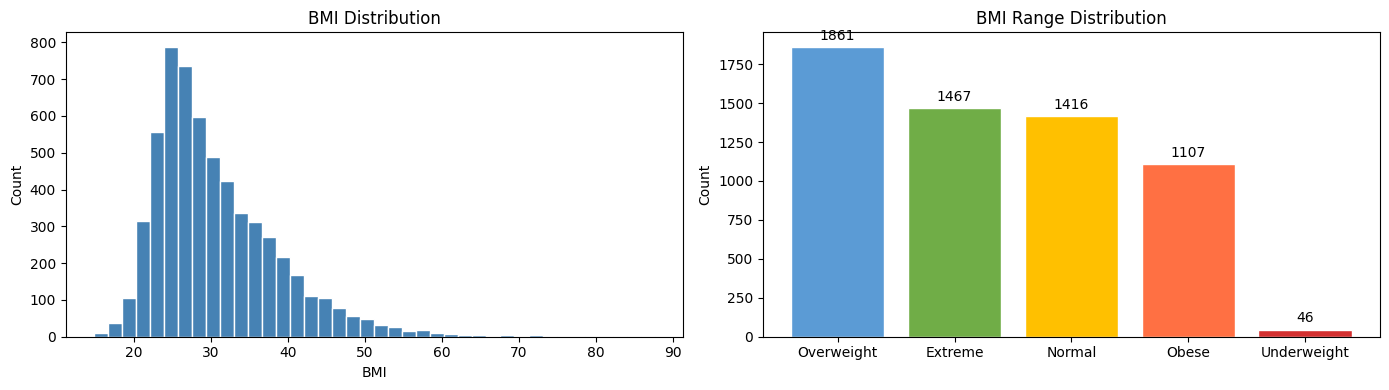


BMI Range Counts:
  Overweight     : 1861  (31.6%)
  Extreme        : 1467  (24.9%)
  Normal         : 1416  (24.0%)
  Obese          : 1107  (18.8%)
  Underweight    :   46  (0.8%)


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution
axes[0].hist(clean_df['bmi'], bins=40,
             color='steelblue', edgecolor='white')
axes[0].set_title('BMI Distribution')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Count')

# Range counts
bins   = [0, 18.5, 25, 30, 35, 100]
labels = ['Underweight', 'Normal', 'Overweight', 'Obese', 'Extreme']
counts = pd.cut(clean_df['bmi'], bins=bins,
                labels=labels).value_counts()

colors = ['#5B9BD5','#70AD47','#FFC000','#FF7043','#D32F2F']
bars   = axes[1].bar(counts.index, counts.values,
                      color=colors, edgecolor='white')
axes[1].bar_label(bars, padding=3)
axes[1].set_title('BMI Range Distribution')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(f'{RESULTS}/bmi_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\nBMI Range Counts:")
for label, count in counts.items():
    pct = count / len(clean_df) * 100
    print(f"  {label:<15}: {count:>4}  ({pct:.1f}%)")

In [17]:
from sklearn.model_selection import train_test_split

unique_persons = clean_df['person_id'].unique()

train_persons, test_persons = train_test_split(
    unique_persons, test_size=0.2, random_state=42
)

train_df = clean_df[clean_df['person_id'].isin(train_persons)].reset_index(drop=True)
test_df  = clean_df[clean_df['person_id'].isin(test_persons)].reset_index(drop=True)

print(f"Train : {len(train_df)} samples  ({len(train_persons)} persons)")
print(f"Test  : {len(test_df)}  samples  ({len(test_persons)} persons)")
print(f"\nTrain BMI : {train_df['bmi'].mean():.2f} ± {train_df['bmi'].std():.2f}")
print(f"Test  BMI : {test_df['bmi'].mean():.2f} ± {test_df['bmi'].std():.2f}")

# Save splits
train_df.to_csv(f'{METRICS}/train_df_raw.csv', index=False)
test_df.to_csv(f'{METRICS}/test_df_raw.csv',   index=False)
print("\n✅ Raw splits saved")

Train : 4717 samples  (2359 persons)
Test  : 1180  samples  (590 persons)

Train BMI : 30.67 ± 8.13
Test  BMI : 31.24 ± 8.70

✅ Raw splits saved


In [18]:
from utils.face_detection import process_all_faces

# Run on full dataset
crops_df = process_all_faces(
    df       = clean_df,
    raw_base = RAW_BASE,
    crops_dir= CROPS,
    device   = device
)

print(f"\nCrop dataframe shape : {crops_df.shape}")
print(crops_df.head(3))

# Save crops dataframe
crops_df.to_csv(f'{METRICS}/crops_df.csv', index=False)
print("✅ Crops dataframe saved")

Detecting faces: 100%|██████████| 5897/5897 [16:21<00:00,  6.01it/s]


✅ Face detection complete
   Success : 5741
   Failed  : 156
   Rate    : 97.4%

Crop dataframe shape : (5741, 3)
                                           crop_path person_id    bmi
0  /kaggle/working/face_crops/2a42h0_h6VenpC_225_...    2a42h0  31.38
1  /kaggle/working/face_crops/2a42h0_z6VenpC_216_...    2a42h0  30.12
2  /kaggle/working/face_crops/2xraoq_PbDJbcx_213_...    2xraoq  34.38
✅ Crops dataframe saved


In [19]:
# Match crops to train/test split using person_id
train_crops = crops_df[crops_df['person_id'].isin(train_persons)].reset_index(drop=True)
test_crops  = crops_df[crops_df['person_id'].isin(test_persons)].reset_index(drop=True)

print(f"Train crops : {len(train_crops)}")
print(f"Test  crops : {len(test_crops)}")

# Check for leakage
train_ids = set(train_crops['person_id'].unique())
test_ids  = set(test_crops['person_id'].unique())
overlap   = train_ids & test_ids
print(f"\nPerson overlap (should be 0) : {len(overlap)}")

# BMI distribution check
print(f"\nTrain BMI : {train_crops['bmi'].mean():.2f} ± {train_crops['bmi'].std():.2f}")
print(f"Test  BMI : {test_crops['bmi'].mean():.2f} ± {test_crops['bmi'].std():.2f}")

# Save final splits
train_crops.to_csv(f'{METRICS}/train_crops.csv', index=False)
test_crops.to_csv(f'{METRICS}/test_crops.csv',   index=False)
print("\n✅ Final crop splits saved")

Train crops : 4587
Test  crops : 1154

Person overlap (should be 0) : 0

Train BMI : 30.68 ± 8.15
Test  BMI : 31.33 ± 8.72

✅ Final crop splits saved


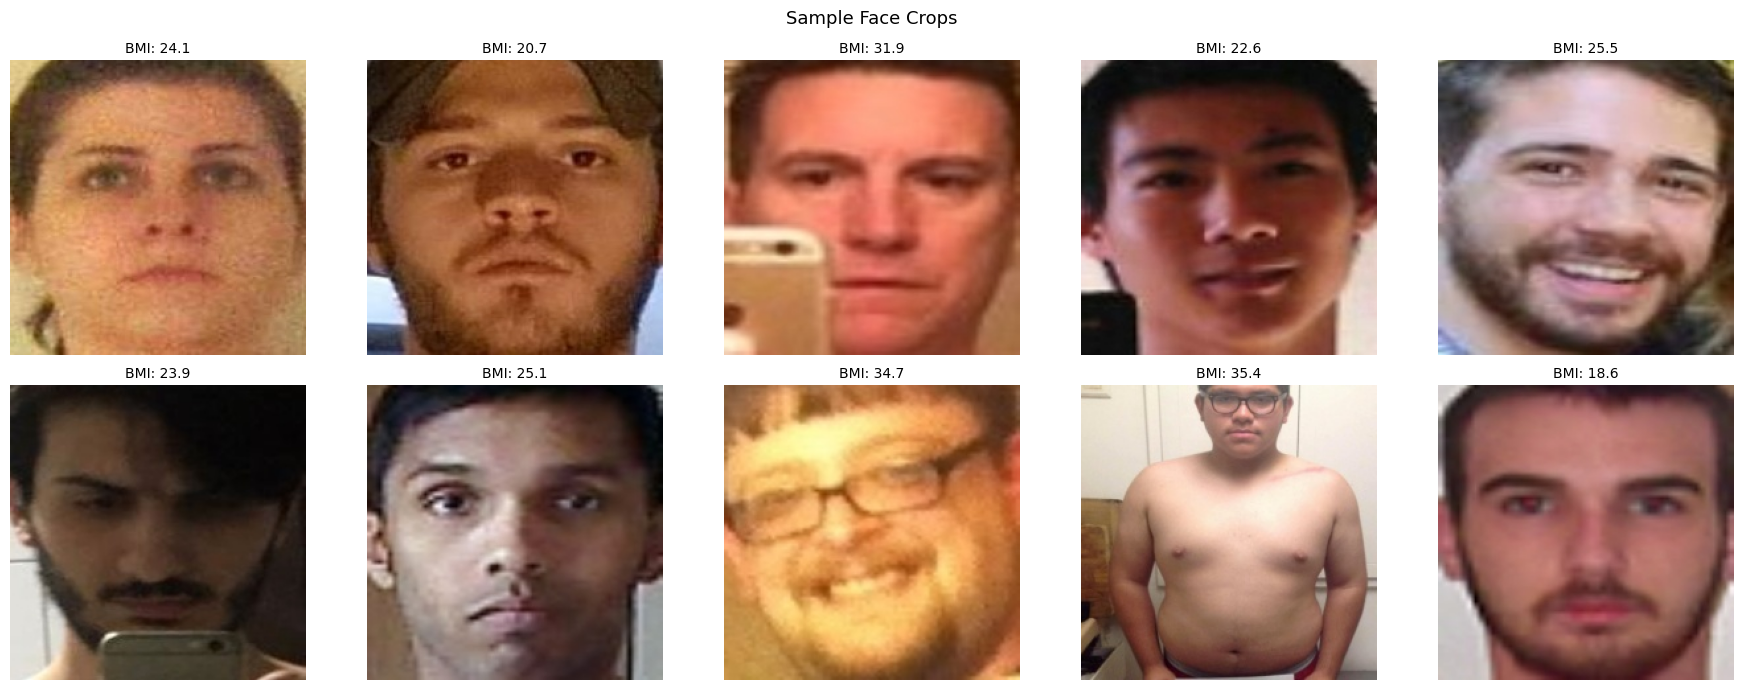

✅ Sample crops verified


In [20]:
import random

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

samples = train_crops.sample(10, random_state=42).reset_index(drop=True)

for i, (_, row) in enumerate(samples.iterrows()):
    img = cv2.imread(row['crop_path'])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img)
    axes[i].set_title(f"BMI: {row['bmi']:.1f}", fontsize=10)
    axes[i].axis('off')

plt.suptitle('Sample Face Crops', fontsize=13)
plt.tight_layout()
plt.savefig(f'{RESULTS}/sample_crops.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sample crops verified")

In [32]:
import yaml
from utils.models import get_model, ModelEMA
from utils.train import SAM, EarlyStopping, train_one_epoch, validate
from utils.dataset import BMIDataset, get_transforms, get_tta_transforms, get_sampler
from utils.evaluate import compute_metrics, predict_tta, plot_predicted_vs_actual, plot_residuals, plot_bmi_range_errors
from utils.model_selection import find_best_alpha, rank_models
from utils.utils import save_model, save_results, save_json

with open('/kaggle/working/configs/model_config.yaml', 'r') as f:
    model_cfg = yaml.safe_load(f)

with open('/kaggle/working/configs/train_config.yaml', 'r') as f:
    train_cfg = yaml.safe_load(f)

# Force correct types — YAML reads scientific notation as string
EPOCHS        = int(train_cfg['training']['epochs'])
BATCH_SIZE    = int(train_cfg['training']['batch_size'])
LR_HEAD       = float(train_cfg['training']['lr_head'])
LR_BACKBONE   = float(train_cfg['training']['lr_backbone'])
WEIGHT_DECAY  = float(train_cfg['training']['weight_decay'])
PATIENCE      = int(train_cfg['training']['patience'])
FREEZE_EPOCHS = int(train_cfg['training']['freeze_epochs'])
NUM_WORKERS   = int(train_cfg['training']['num_workers'])
HUBER_DELTA   = float(train_cfg['loss']['delta'])

print("✅ Configs loaded")
print(f"   Epochs       : {EPOCHS}        ({type(EPOCHS).__name__})")
print(f"   Batch size   : {BATCH_SIZE}       ({type(BATCH_SIZE).__name__})")
print(f"   LR head      : {LR_HEAD}     ({type(LR_HEAD).__name__})")
print(f"   LR backbone  : {LR_BACKBONE}    ({type(LR_BACKBONE).__name__})")
print(f"   Weight decay : {WEIGHT_DECAY}    ({type(WEIGHT_DECAY).__name__})")
print(f"   Patience     : {PATIENCE}         ({type(PATIENCE).__name__})")
print(f"   Freeze epochs: {FREEZE_EPOCHS}         ({type(FREEZE_EPOCHS).__name__})")

✅ Configs loaded
   Epochs       : 30        (int)
   Batch size   : 32       (int)
   LR head      : 0.001     (float)
   LR backbone  : 0.0001    (float)
   Weight decay : 0.0001    (float)
   Patience     : 5         (int)
   Freeze epochs: 5         (int)


In [26]:
def train_model(model_name, arch, dropout=0.4):
    print(f"\n{'='*60}")
    print(f"  Training : {model_name}")
    print(f"{'='*60}")

    # --- Datasets ---
    train_transform = get_transforms(224, mode='train')
    val_transform   = get_transforms(224, mode='val')

    train_dataset = BMIDataset(train_crops, train_transform)
    test_dataset  = BMIDataset(test_crops,  val_transform)

    sampler      = get_sampler(train_crops)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                              sampler=sampler, num_workers=NUM_WORKERS,
                              pin_memory=True)
    test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                              shuffle=False,  num_workers=NUM_WORKERS,
                              pin_memory=True)

    # --- Model ---
    model = get_model(arch, dropout=dropout).to(device)
    ema   = ModelEMA(model, decay=0.995)

    # --- Loss ---
    criterion = nn.HuberLoss(delta=HUBER_DELTA)

    # --- Scaler for mixed precision ---
    scaler = GradScaler()

    # --- Phase 1: freeze backbone, train head only ---
    model.freeze_backbone()
    optimizer = SAM(
        [{'params': model.head.parameters()}],
        torch.optim.AdamW,
        lr=LR_HEAD,
        weight_decay=WEIGHT_DECAY
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer.base_optimizer, T_0=10, T_mult=2
    )

    # --- Early stopping ---
    early_stop = EarlyStopping(patience=PATIENCE)

    # --- History ---
    history = {
        'train_loss': [], 'val_loss': [],
        'train_mae':  [], 'val_mae':  []
    }

    best_val_mae  = float('inf')
    best_weights  = None

    print(f"\n--- Phase 1: Head only ({FREEZE_EPOCHS} epochs) ---")

    for epoch in range(1, EPOCHS + 1):

        # Switch to full fine-tuning after freeze epochs
        if epoch == FREEZE_EPOCHS + 1:
            print(f"\n--- Phase 2: Full fine-tune (epoch {epoch} onwards) ---")
            model.unfreeze_backbone()
            optimizer = SAM(
                [
                    {'params': model.backbone.parameters(),
                     'lr': LR_BACKBONE},
                    {'params': model.head.parameters(),
                     'lr': LR_HEAD}
                ],
                torch.optim.AdamW,
                lr=LR_BACKBONE,
                weight_decay=WEIGHT_DECAY
            )
            scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
                optimizer.base_optimizer, T_0=10, T_mult=2
            )

        train_loss, train_mae = train_one_epoch(
            model, train_loader, criterion,
            optimizer, scaler, device, ema, use_sam=True
        )
        val_loss, val_mae, val_preds, val_labels = validate(
            model, test_loader, criterion, device
        )

        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_mae'].append(train_mae)
        history['val_mae'].append(val_mae)

        # Save best weights
        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_weights = {k: v.clone() for k, v in
                            model.state_dict().items()}
            tag = ' ← best'
        else:
            tag = ''

        print(f"  Epoch {epoch:>3}/{EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Train MAE: {train_mae:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val MAE: {val_mae:.4f}{tag}")

        early_stop(val_mae)
        if early_stop.stop:
            print(f"\n  Early stopping at epoch {epoch}")
            break

    # --- Load best weights ---
    model.load_state_dict(best_weights)

    # --- TTA predictions ---
    print("\nRunning TTA predictions...")
    tta_transforms = get_tta_transforms(224)
    tta_preds      = predict_tta(model, test_dataset,
                                  tta_transforms, device,
                                  batch_size=BATCH_SIZE)
    tta_labels     = test_crops['bmi'].values

    # --- Metrics ---
    metrics = compute_metrics(tta_labels, tta_preds, model_name)
    print(f"\n  Final metrics (with TTA):")
    for k, v in metrics.items():
        print(f"    {k:<15}: {v}")

    # --- Save model ---
    save_path = f'{MODELS}/{model_name.lower().replace(" ","_")}.pth'
    save_model(model, save_path, config={
        'arch':    arch,
        'dropout': dropout,
        'img_size': 224
    })

    # --- Save EMA model ---
    ema_path = f'{MODELS}/{model_name.lower().replace(" ","_")}_ema.pth'
    save_model(ema.ema, ema_path)

    # --- Plots ---
    plot_predicted_vs_actual(
        tta_labels, tta_preds, model_name,
        f'{RESULTS}/{model_name.lower().replace(" ","_")}_pred_vs_actual.png'
    )
    plot_residuals(
        tta_labels, tta_preds, model_name,
        f'{RESULTS}/{model_name.lower().replace(" ","_")}_residuals.png'
    )
    plot_bmi_range_errors(
        tta_labels, tta_preds, model_name,
        f'{RESULTS}/{model_name.lower().replace(" ","_")}_range_errors.png'
    )

    # --- Training curves ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history['train_loss'], label='Train')
    axes[0].plot(history['val_loss'],   label='Val')
    axes[0].set_title(f'{model_name} — Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(history['train_mae'], label='Train')
    axes[1].plot(history['val_mae'],   label='Val')
    axes[1].set_title(f'{model_name} — MAE')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(
        f'{RESULTS}/{model_name.lower().replace(" ","_")}_curves.png',
        dpi=150, bbox_inches='tight'
    )
    plt.show()

    return metrics, history, tta_preds

In [30]:
import importlib
import utils.dataset
importlib.reload(utils.dataset)

from utils.dataset import BMIDataset, get_transforms, get_tta_transforms, get_sampler

print("✅ dataset.py reloaded — now rerun Cell 19")

✅ dataset.py reloaded — now rerun Cell 19


In [35]:
import importlib
import utils.train
importlib.reload(utils.train)

from utils.train import SAM, EarlyStopping, train_one_epoch, validate
print("✅ train.py reloaded — rerun Cell 19")

✅ train.py reloaded — rerun Cell 19



  Training : EfficientNet-B3

--- Phase 1: Head only (5 epochs) ---
  Epoch   1/30 | Train Loss: 9.3458 | Train MAE: 9.8335 | Val Loss: 6.7943 | Val MAE: 7.2776 ← best
  Epoch   2/30 | Train Loss: 6.6059 | Train MAE: 7.0907 | Val Loss: 6.4915 | Val MAE: 6.9710 ← best
  Epoch   3/30 | Train Loss: 6.5244 | Train MAE: 7.0090 | Val Loss: 6.4045 | Val MAE: 6.8871 ← best
  Epoch   4/30 | Train Loss: 6.3389 | Train MAE: 6.8230 | Val Loss: 6.1947 | Val MAE: 6.6753 ← best
  Epoch   5/30 | Train Loss: 6.0709 | Train MAE: 6.5530 | Val Loss: 6.2451 | Val MAE: 6.7277

--- Phase 2: Full fine-tune (epoch 6 onwards) ---
  Epoch   6/30 | Train Loss: 6.8248 | Train MAE: 7.3109 | Val Loss: 7.0542 | Val MAE: 7.5396
  Epoch   7/30 | Train Loss: 6.3688 | Train MAE: 6.8522 | Val Loss: 5.8634 | Val MAE: 6.3475 ← best
  Epoch   8/30 | Train Loss: 5.7609 | Train MAE: 6.2414 | Val Loss: 5.0145 | Val MAE: 5.4908 ← best
  Epoch   9/30 | Train Loss: 5.4487 | Train MAE: 5.9276 | Val Loss: 5.0712 | Val MAE: 5.5450
 

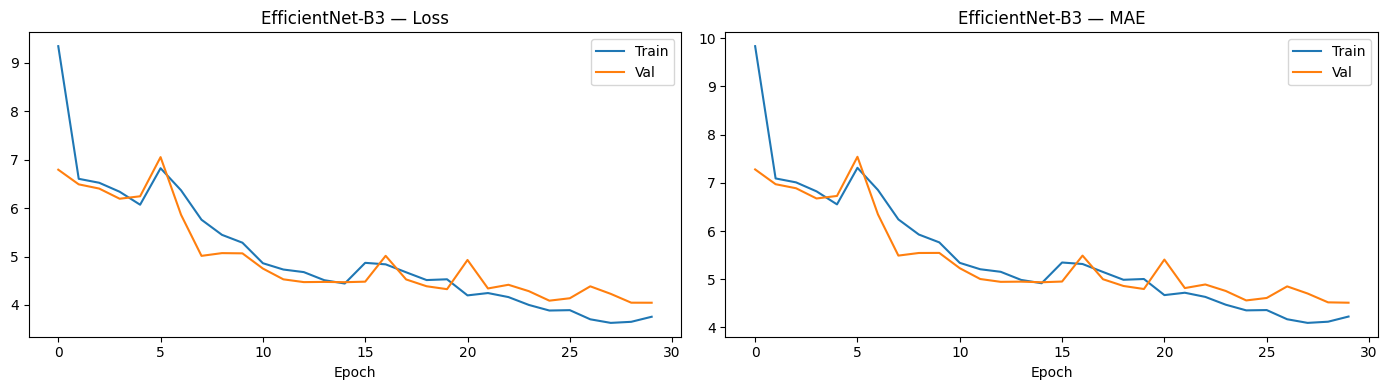

✅ Results saved: /kaggle/working/results/metrics/results_so_far.csv

✅ EfficientNet-B3 complete


  Training : EfficientNet-B4


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]


--- Phase 1: Head only (5 epochs) ---
  Epoch   1/30 | Train Loss: 9.4073 | Train MAE: 9.8940 | Val Loss: 7.2647 | Val MAE: 7.7505 ← best
  Epoch   2/30 | Train Loss: 6.7112 | Train MAE: 7.1937 | Val Loss: 6.4104 | Val MAE: 6.8908 ← best
  Epoch   3/30 | Train Loss: 6.3273 | Train MAE: 6.8113 | Val Loss: 6.1503 | Val MAE: 6.6320 ← best
  Epoch   4/30 | Train Loss: 6.0707 | Train MAE: 6.5538 | Val Loss: 6.2313 | Val MAE: 6.7124
  Epoch   5/30 | Train Loss: 5.9722 | Train MAE: 6.4543 | Val Loss: 5.9419 | Val MAE: 6.4282 ← best

--- Phase 2: Full fine-tune (epoch 6 onwards) ---
  Epoch   6/30 | Train Loss: 6.3157 | Train MAE: 6.7990 | Val Loss: 5.8931 | Val MAE: 6.3743 ← best
  Epoch   7/30 | Train Loss: 6.0443 | Train MAE: 6.5272 | Val Loss: 5.8034 | Val MAE: 6.2814 ← best
  Epoch   8/30 | Train Loss: 5.7820 | Train MAE: 6.2631 | Val Loss: 5.3661 | Val MAE: 5.8437 ← best
  Epoch   9/30 | Train Loss: 5.6526 | Train MAE: 6.1331 | Val Loss: 5.3617 | Val MAE: 5.8415 ← best
  Epoch  10/30 | 

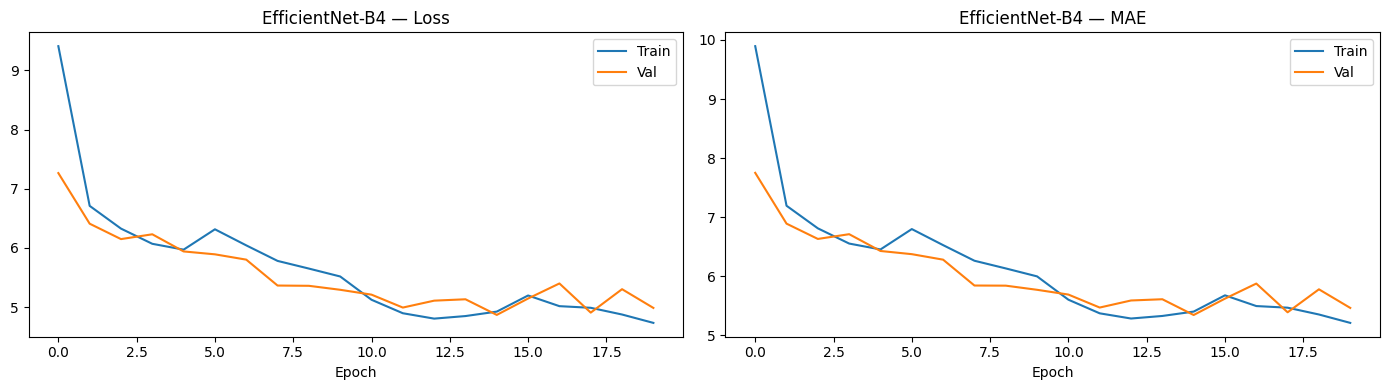

✅ Results saved: /kaggle/working/results/metrics/results_so_far.csv

✅ EfficientNet-B4 complete


  Training : ResNet-50


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]


--- Phase 1: Head only (5 epochs) ---
  Epoch   1/30 | Train Loss: 10.1976 | Train MAE: 10.6857 | Val Loss: 6.7686 | Val MAE: 7.2536 ← best
  Epoch   2/30 | Train Loss: 6.9004 | Train MAE: 7.3842 | Val Loss: 7.5248 | Val MAE: 8.0031
  Epoch   3/30 | Train Loss: 6.7310 | Train MAE: 7.2154 | Val Loss: 6.7149 | Val MAE: 7.2013 ← best
  Epoch   4/30 | Train Loss: 6.8090 | Train MAE: 7.2946 | Val Loss: 6.1258 | Val MAE: 6.6096 ← best
  Epoch   5/30 | Train Loss: 6.3463 | Train MAE: 6.8299 | Val Loss: 6.0745 | Val MAE: 6.5525 ← best

--- Phase 2: Full fine-tune (epoch 6 onwards) ---
  Epoch   6/30 | Train Loss: 7.1017 | Train MAE: 7.5883 | Val Loss: 6.0224 | Val MAE: 6.5094 ← best
  Epoch   7/30 | Train Loss: 6.7337 | Train MAE: 7.2191 | Val Loss: 5.9702 | Val MAE: 6.4490 ← best
  Epoch   8/30 | Train Loss: 6.4503 | Train MAE: 6.9347 | Val Loss: 5.6677 | Val MAE: 6.1463 ← best
  Epoch   9/30 | Train Loss: 6.1965 | Train MAE: 6.6803 | Val Loss: 5.4929 | Val MAE: 5.9719 ← best
  Epoch  10/30 

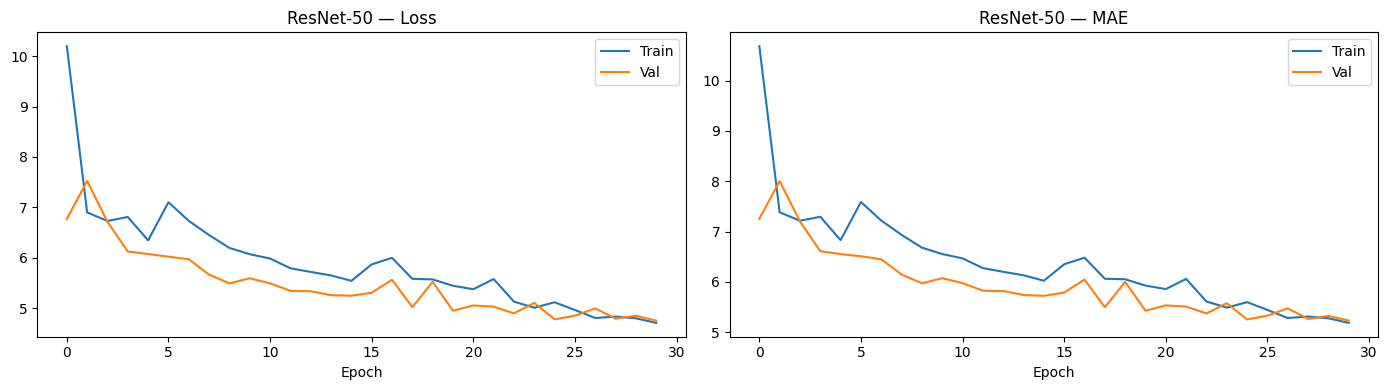

✅ Results saved: /kaggle/working/results/metrics/results_so_far.csv

✅ ResNet-50 complete


  Training : Swin-Tiny


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]


--- Phase 1: Head only (5 epochs) ---
  Epoch   1/30 | Train Loss: 9.2243 | Train MAE: 9.7106 | Val Loss: 6.6670 | Val MAE: 7.1496 ← best
  Epoch   2/30 | Train Loss: 6.4689 | Train MAE: 6.9515 | Val Loss: 7.0546 | Val MAE: 7.5397
  Epoch   3/30 | Train Loss: 6.2748 | Train MAE: 6.7557 | Val Loss: 6.0400 | Val MAE: 6.5225 ← best
  Epoch   4/30 | Train Loss: 5.9644 | Train MAE: 6.4473 | Val Loss: 6.0921 | Val MAE: 6.5747
  Epoch   5/30 | Train Loss: 5.9863 | Train MAE: 6.4688 | Val Loss: 5.6281 | Val MAE: 6.1088 ← best

--- Phase 2: Full fine-tune (epoch 6 onwards) ---
  Epoch   6/30 | Train Loss: 7.6017 | Train MAE: 8.0871 | Val Loss: 6.2743 | Val MAE: 6.7561
  Epoch   7/30 | Train Loss: 7.0276 | Train MAE: 7.5144 | Val Loss: 5.4054 | Val MAE: 5.8840 ← best
  Epoch   8/30 | Train Loss: 6.4440 | Train MAE: 6.9271 | Val Loss: 5.5045 | Val MAE: 5.9827
  Epoch   9/30 | Train Loss: 5.8935 | Train MAE: 6.3740 | Val Loss: 5.0393 | Val MAE: 5.5192 ← best
  Epoch  10/30 | Train Loss: 5.8392 | 

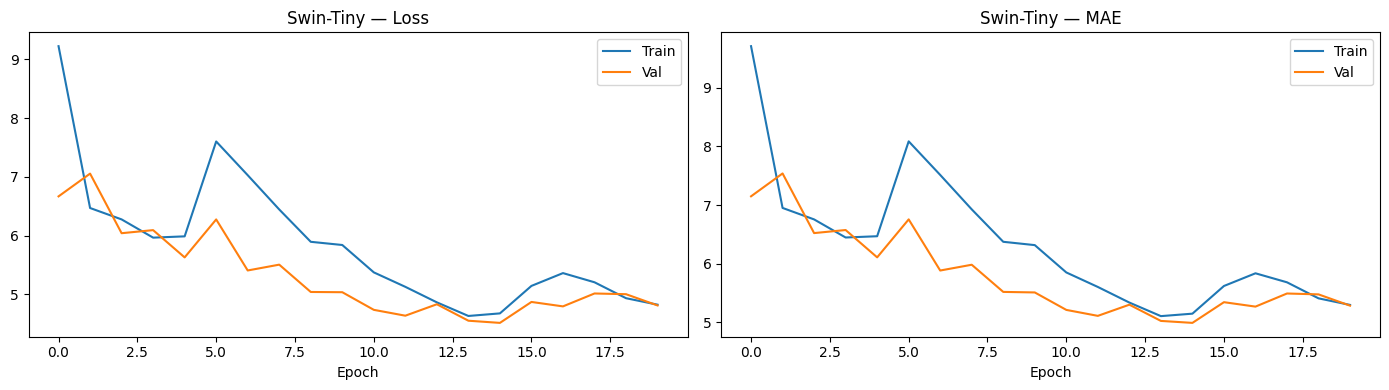

✅ Results saved: /kaggle/working/results/metrics/results_so_far.csv

✅ Swin-Tiny complete



In [37]:
# Model definitions from config
models_to_train = [
    ('EfficientNet-B3', 'efficientnet_b3',               0.4),
    ('EfficientNet-B4', 'efficientnet_b4',               0.4),
    ('ResNet-50',       'resnet50',                      0.4),
    ('Swin-Tiny',       'swin_tiny_patch4_window7_224',  0.4),
]

all_results  = []
all_histories = {}
all_preds    = {}

for model_name, arch, dropout in models_to_train:
    metrics, history, preds = train_model(model_name, arch, dropout)
    all_results.append(metrics)
    all_histories[model_name] = history
    all_preds[model_name]     = preds

    # Save intermediate results after each model
    save_results(all_results, f'{METRICS}/results_so_far.csv')
    print(f"\n✅ {model_name} complete\n")

In [38]:
# Full results table
results_df = pd.DataFrame(all_results).sort_values('MAE').reset_index(drop=True)
results_df.index += 1

print("\n" + "="*80)
print("          BMI PREDICTION — DEEP LEARNING MODEL COMPARISON")
print("="*80)
print(results_df.to_string())
print("="*80)

# Save
results_df.to_csv(f'{METRICS}/final_metrics.csv', index=True)
print("\n✅ Final metrics saved")


          BMI PREDICTION — DEEP LEARNING MODEL COMPARISON
             Model     MAE    RMSE      R2  MAPE%  Pearson    Bias  Extreme_MAE
1  EfficientNet-B3  4.4895  6.7574  0.3983  13.38   0.6574 -1.5160       8.5461
2        Swin-Tiny  4.9559  7.2647  0.3046  14.84   0.5862 -1.7210       9.1593
3        ResNet-50  5.1851  7.5976  0.2394  15.72   0.5109 -1.2802       9.6364
4  EfficientNet-B4  5.2165  7.6601  0.2268  15.65   0.5117 -1.6287       9.9210

✅ Final metrics saved


In [39]:
# Find optimal alpha via Optuna
best_alpha = find_best_alpha(all_results)

# Rank models
ranked = rank_models(all_results, best_alpha)
ranked_df = pd.DataFrame(ranked)

print(f"\nOptuna best alpha : {best_alpha:.4f}")
print(f"  → MAE weight : {best_alpha:.4f}")
print(f"  → R²  weight : {1-best_alpha:.4f}")

print("\nModel Rankings:")
print("="*70)
for i, r in enumerate(ranked):
    print(f"  #{i+1}  {r['Model']:<20} "
          f"MAE={r['MAE']:.4f}  "
          f"R²={r['R2']:.4f}  "
          f"Score={r['Score']:.6f}")
print("="*70)

# Save alpha
save_json({'best_alpha': best_alpha,
           'mae_weight': best_alpha,
           'r2_weight':  1 - best_alpha},
          f'{METRICS}/optuna_alpha.json')

# Top 2
top2 = ranked[:2]
print(f"\n🏆 Best 2 models:")
print(f"   #1 : {top2[0]['Model']}")
print(f"   #2 : {top2[1]['Model']}")

✅ Optuna best alpha : 0.0000

Optuna best alpha : 0.0000
  → MAE weight : 0.0000
  → R²  weight : 1.0000

Model Rankings:
  #1  EfficientNet-B3      MAE=4.4895  R²=0.3983  Score=0.398300
  #2  Swin-Tiny            MAE=4.9559  R²=0.3046  Score=0.304600
  #3  ResNet-50            MAE=5.1851  R²=0.2394  Score=0.239400
  #4  EfficientNet-B4      MAE=5.2165  R²=0.2268  Score=0.226800
✅ JSON saved: /kaggle/working/results/metrics/optuna_alpha.json

🏆 Best 2 models:
   #1 : EfficientNet-B3
   #2 : Swin-Tiny


In [40]:
import shutil

for rank, r in enumerate(top2, 1):
    name     = r['Model'].lower().replace(' ', '_').replace('-', '_')
    src_path = f'{MODELS}/{name}.pth'
    dst_path = f'{MODELS}/BEST_{rank}_{r["Model"].replace(" ","_")}.pth'

    if os.path.exists(src_path):
        shutil.copy(src_path, dst_path)
        print(f"✅ Saved Best #{rank} : {dst_path}")
    else:
        print(f"❌ Not found: {src_path}")

print(f"\nAll saved models:")
for f in sorted(os.listdir(MODELS)):
    size = os.path.getsize(f'{MODELS}/{f}') / 1e6
    print(f"   {f}  ({size:.1f} MB)")

❌ Not found: /kaggle/working/saved_models/efficientnet_b3.pth
❌ Not found: /kaggle/working/saved_models/swin_tiny.pth

All saved models:
   efficientnet-b3.pth  (46.8 MB)
   efficientnet-b3_config.yaml  (0.0 MB)
   efficientnet-b3_ema.pth  (46.8 MB)
   efficientnet-b4.pth  (74.9 MB)
   efficientnet-b4_config.yaml  (0.0 MB)
   efficientnet-b4_ema.pth  (74.9 MB)
   resnet-50.pth  (98.8 MB)
   resnet-50_config.yaml  (0.0 MB)
   resnet-50_ema.pth  (98.8 MB)
   swin-tiny.pth  (112.0 MB)
   swin-tiny_config.yaml  (0.0 MB)
   swin-tiny_ema.pth  (112.0 MB)


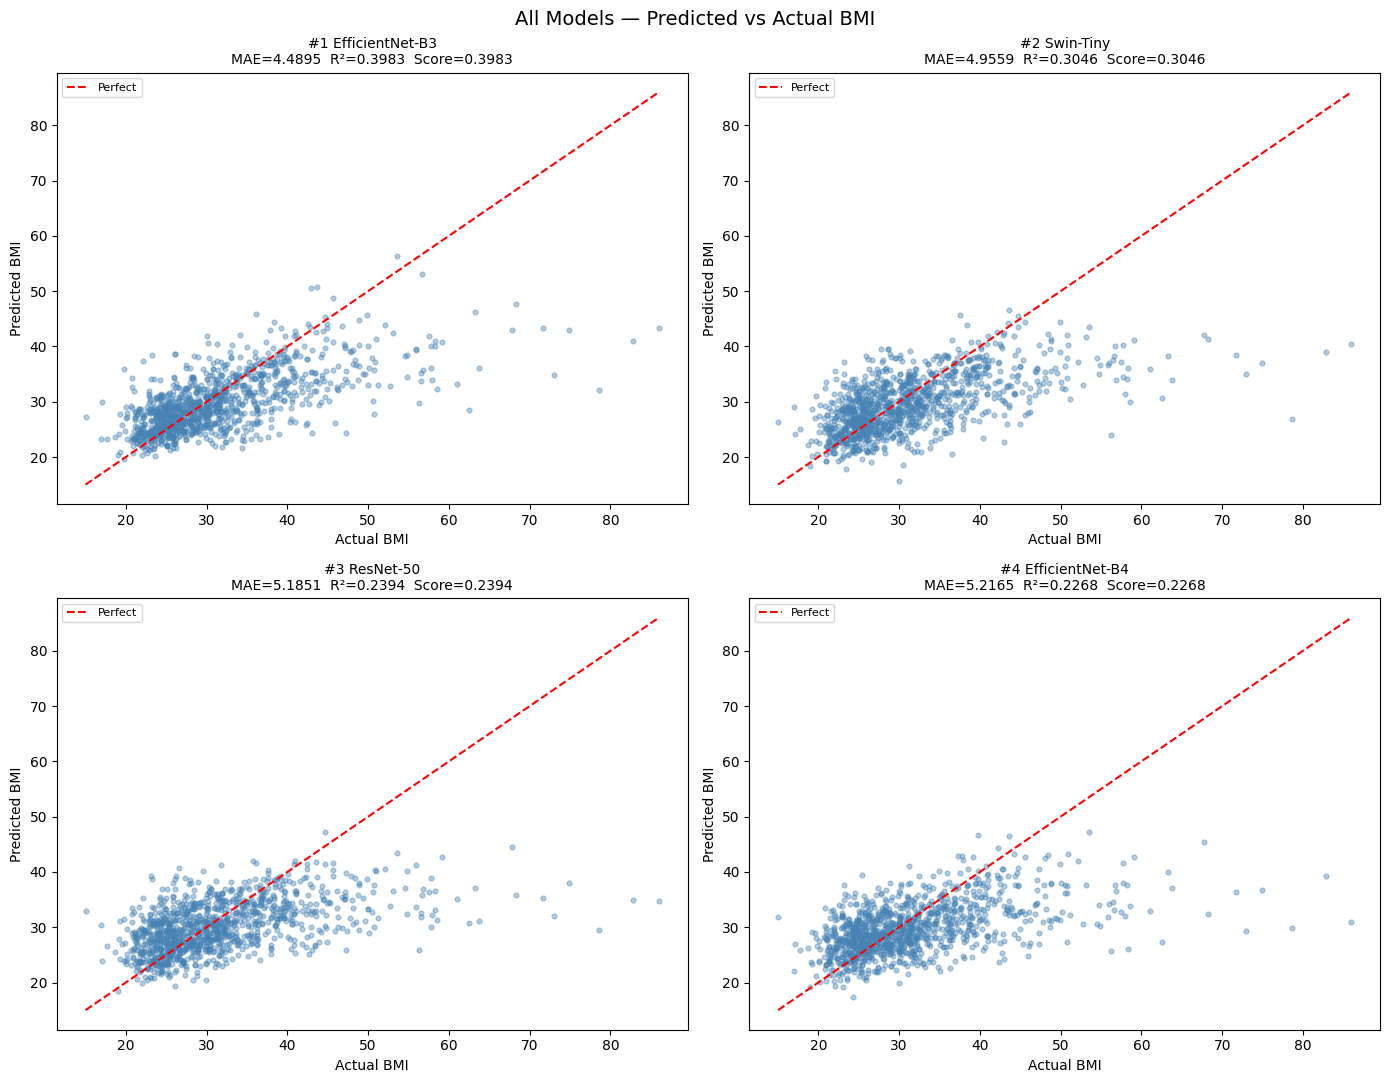

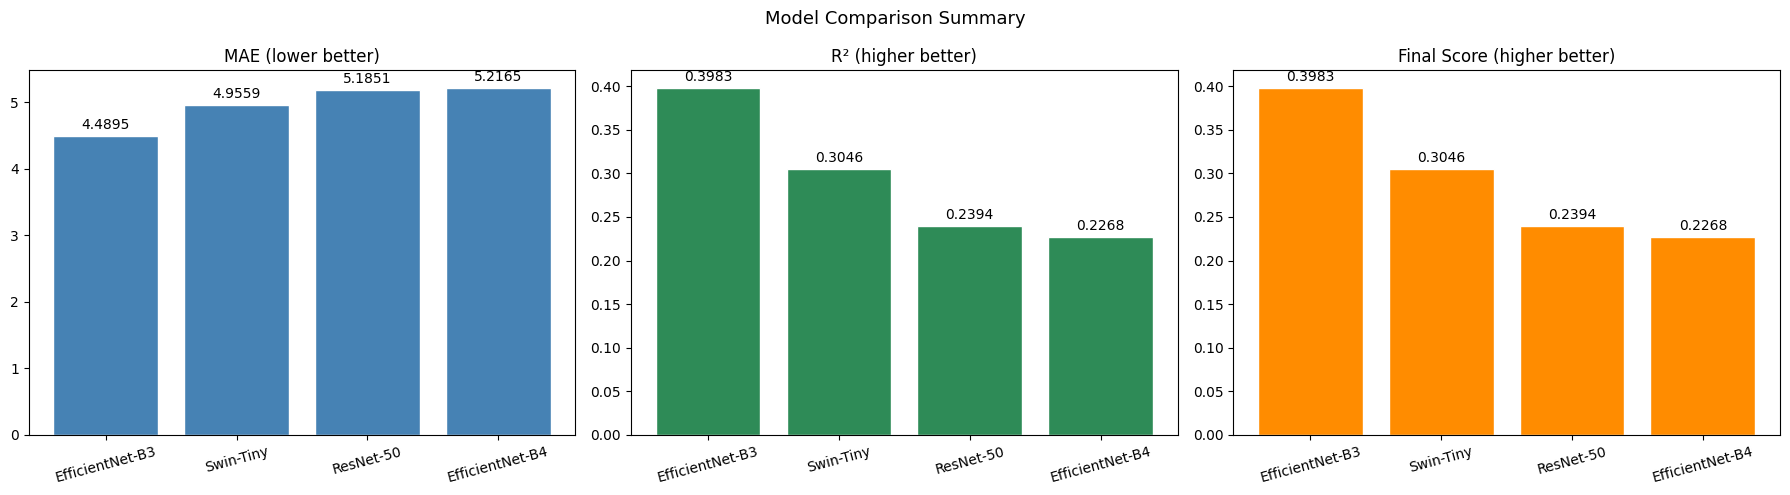

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for i, r in enumerate(ranked):
    name  = r['Model']
    preds = all_preds[name]
    labels= test_crops['bmi'].values
    ax    = axes[i]

    ax.scatter(labels, preds, alpha=0.4, s=12, color='steelblue')
    mn, mx = float(min(labels)), float(max(labels))
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect')
    ax.set_title(f"#{i+1} {name}\nMAE={r['MAE']}  R²={r['R2']}  "
                 f"Score={r['Score']:.4f}", fontsize=10)
    ax.set_xlabel('Actual BMI')
    ax.set_ylabel('Predicted BMI')
    ax.legend(fontsize=8)

plt.suptitle('All Models — Predicted vs Actual BMI', fontsize=14)
plt.tight_layout()
plt.savefig(f'{RESULTS}/all_models_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

names = [r['Model'] for r in ranked]
maes  = [r['MAE']   for r in ranked]
r2s   = [r['R2']    for r in ranked]
scores= [r['Score'] for r in ranked]

for ax, vals, label, color in zip(
    axes,
    [maes, r2s, scores],
    ['MAE (lower better)', 'R² (higher better)', 'Final Score (higher better)'],
    ['steelblue', 'seagreen', 'darkorange']
):
    bars = ax.bar(names, vals, color=color, edgecolor='white')
    ax.bar_label(bars, fmt='%.4f', padding=3)
    ax.set_title(label)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Model Comparison Summary', fontsize=13)
plt.tight_layout()
plt.savefig(f'{RESULTS}/final_bar_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [42]:
%%writefile /kaggle/working/utils/ensemble_utils.py

import numpy as np
import torch
from tqdm import tqdm

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# =========================================================
# GENERATE PREDICTIONS
# =========================================================

def generate_predictions(model, loader, device):

    model.eval()

    preds = []
    targets = []

    with torch.no_grad():

        for images, labels in tqdm(loader):

            images = images.to(device)

            outputs = model(images).squeeze(1)

            preds.extend(outputs.cpu().numpy())
            targets.extend(labels.numpy())

    preds = np.array(preds)
    targets = np.array(targets)

    return preds, targets


# =========================================================
# EVALUATE METRICS
# =========================================================

def evaluate_regression(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    r2 = r2_score(y_true, y_pred)

    return {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    }

Writing /kaggle/working/utils/ensemble_utils.py


In [46]:
import importlib
import utils.models
importlib.reload(utils.models)
from utils.models import get_model
from utils.dataset import BMIDataset, get_tta_transforms
from utils.evaluate import compute_metrics, predict_tta, plot_predicted_vs_actual, plot_residuals, plot_bmi_range_errors
from utils.utils import load_model

# Rebuild both models and load weights
b3_model   = get_model('efficientnet_b3', dropout=0.4).to(device)
swin_model = get_model('swin_tiny_patch4_window7_224', dropout=0.4).to(device)

b3_model   = load_model(b3_model,
                         f'{MODELS}/efficientnet-b3.pth', device)
swin_model = load_model(swin_model,
                         f'{MODELS}/swin-tiny.pth', device)

print("✅ Both models loaded")

# TTA predictions from both
tta_transforms = get_tta_transforms(224)
test_transform = get_transforms(224, mode='val')
test_dataset   = BMIDataset(test_crops, test_transform)
true_labels    = test_crops['bmi'].values

print("\nGenerating B3 TTA predictions...")
b3_preds   = predict_tta(b3_model,   test_dataset,
                          tta_transforms, device, batch_size=32)

print("Generating Swin-T TTA predictions...")
swin_preds = predict_tta(swin_model, test_dataset,
                          tta_transforms, device, batch_size=32)

print(f"\n✅ Predictions ready")
print(f"   B3   MAE : {np.mean(np.abs(true_labels - b3_preds)):.4f}")
print(f"   Swin MAE : {np.mean(np.abs(true_labels - swin_preds)):.4f}")

✅ Both models loaded

Generating B3 TTA predictions...
Generating Swin-T TTA predictions...

✅ Predictions ready
   B3   MAE : 4.4921
   Swin MAE : 4.9530


In [49]:
import optuna
from sklearn.metrics import mean_absolute_error

def find_best_ensemble_weights(b3_preds, swin_preds, true_labels):
    def objective(trial):
        w_b3   = trial.suggest_float('w_b3', 0.0, 1.0)
        w_swin = 1.0 - w_b3
        ensemble_preds = w_b3 * b3_preds + w_swin * swin_preds
        return mean_absolute_error(true_labels, ensemble_preds)

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=300,
                   show_progress_bar=False)

    best_w_b3   = study.best_params['w_b3']
    best_w_swin = 1.0 - best_w_b3
    best_mae    = study.best_value

    return best_w_b3, best_w_swin, best_mae

print("Running Optuna to find best ensemble weights...")
w_b3, w_swin, best_mae = find_best_ensemble_weights(
    b3_preds, swin_preds, true_labels
)

print(f"\n✅ Best ensemble weights found:")
print(f"   EfficientNet-B3 weight : {w_b3:.4f}")
print(f"   Swin-Tiny weight       : {w_swin:.4f}")
print(f"   Ensemble MAE           : {best_mae:.4f}")

Running Optuna to find best ensemble weights...

✅ Best ensemble weights found:
   EfficientNet-B3 weight : 0.7732
   Swin-Tiny weight       : 0.2268
   Ensemble MAE           : 4.4340


In [51]:
# Check what's available
print("b3_preds   :", 'b3_preds'   in dir(), b3_preds.shape   if 'b3_preds'   in dir() else 'MISSING')
print("swin_preds :", 'swin_preds' in dir(), swin_preds.shape if 'swin_preds' in dir() else 'MISSING')
print("w_b3       :", 'w_b3'       in dir())
print("w_swin     :", 'w_swin'     in dir())
print("true_labels:", 'true_labels' in dir())

b3_preds   : True (1154,)
swin_preds : True (1154,)
w_b3       : True
w_swin     : True
true_labels: True


In [52]:
weighted_preds = w_b3 * b3_preds + w_swin * swin_preds
print(f"✅ weighted_preds created — shape: {weighted_preds.shape}")
print(f"   MAE: {mean_absolute_error(true_labels, weighted_preds):.4f}")

✅ weighted_preds created — shape: (1154,)
   MAE: 4.4340


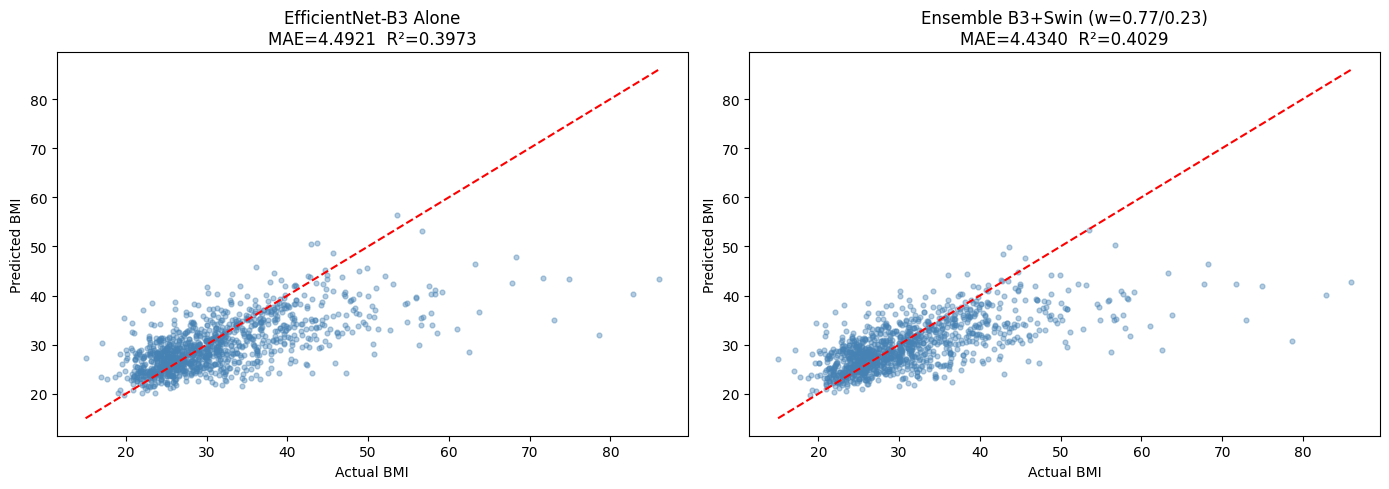

✅ All ensemble plots saved


In [53]:
best_preds = weighted_preds
best_name  = f'Ensemble B3+Swin (w={w_b3:.2f}/{w_swin:.2f})'

# Predicted vs actual
plot_predicted_vs_actual(
    true_labels, best_preds, best_name,
    f'{RESULTS}/ensemble_pred_vs_actual.png'
)

# Residuals
plot_residuals(
    true_labels, best_preds, best_name,
    f'{RESULTS}/ensemble_residuals.png'
)

# BMI range errors
plot_bmi_range_errors(
    true_labels, best_preds, best_name,
    f'{RESULTS}/ensemble_range_errors.png'
)

# Side by side — B3 alone vs ensemble
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, title in zip(
    axes,
    [b3_preds, best_preds],
    ['EfficientNet-B3 Alone', best_name]
):
    mae = mean_absolute_error(true_labels, preds)
    r2  = r2_score(true_labels, preds)
    ax.scatter(true_labels, preds, alpha=0.4, s=12, color='steelblue')
    mn, mx = float(min(true_labels)), float(max(true_labels))
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5)
    ax.set_title(f'{title}\nMAE={mae:.4f}  R²={r2:.4f}')
    ax.set_xlabel('Actual BMI')
    ax.set_ylabel('Predicted BMI')

plt.tight_layout()
plt.savefig(f'{RESULTS}/b3_vs_ensemble.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ All ensemble plots saved")

In [54]:
# Save predictions
pd.DataFrame({
    'true_bmi'      : true_labels,
    'b3_preds'      : b3_preds,
    'swin_preds'    : swin_preds,
    'ensemble_preds': weighted_preds
}).to_csv(f'{PREDS}/ensemble_predictions.csv', index=False)

# Save weights
save_json({
    'type'              : 'weighted_ensemble',
    'models'            : ['efficientnet_b3', 'swin_tiny'],
    'weights'           : [round(w_b3, 4), round(w_swin, 4)],
    'ensemble_MAE'      : round(best_mae, 4),
    'b3_MAE'            : round(mean_absolute_error(
                            true_labels, b3_preds), 4),
    'swin_MAE'          : round(mean_absolute_error(
                            true_labels, swin_preds), 4),
}, f'{METRICS}/ensemble_weights.json')

print(f"\n{'='*50}")
print(f"  FINAL SUMMARY")
print(f"{'='*50}")
print(f"  B3 alone     MAE : {mean_absolute_error(true_labels, b3_preds):.4f}")
print(f"  Ensemble     MAE : {best_mae:.4f}")
print(f"  Improvement      : {mean_absolute_error(true_labels, b3_preds) - best_mae:.4f} BMI units")
print(f"  B3 weight        : {w_b3:.4f}")
print(f"  Swin weight      : {w_swin:.4f}")
print(f"{'='*50}")

✅ JSON saved: /kaggle/working/results/metrics/ensemble_weights.json

  FINAL SUMMARY
  B3 alone     MAE : 4.4921
  Ensemble     MAE : 4.4340
  Improvement      : 0.0581 BMI units
  B3 weight        : 0.7732
  Swin weight      : 0.2268


# new models and increased margins

In [55]:
# New folders for m40 experiment
CROPS_M40   = '/kaggle/working/face_crops_m40'
MODELS_M40  = '/kaggle/working/saved_models_m40'
RESULTS_M40 = '/kaggle/working/results/plots_m40'
METRICS_M40 = '/kaggle/working/results/metrics_m40'

for folder in [CROPS_M40, MODELS_M40, RESULTS_M40, METRICS_M40]:
    os.makedirs(folder, exist_ok=True)

print("✅ M40 folders created")

✅ M40 folders created


In [56]:
%%writefile /kaggle/working/utils/face_detection_m40.py

import os
import cv2
import numpy as np
from PIL import Image
from facenet_pytorch import MTCNN
import torch
from tqdm import tqdm
import pandas as pd


def get_mtcnn_m40(device):
    return MTCNN(
        image_size   = 224,
        margin       = 40,        # increased from 20
        min_face_size= 40,
        thresholds   = [0.6, 0.7, 0.7],
        factor       = 0.709,
        keep_all     = False,
        device       = device
    )


def crop_and_save_face_m40(img_path, save_path, mtcnn):
    try:
        img  = Image.open(img_path).convert('RGB')
        face = mtcnn(img)

        if face is None:
            return False

        face_np  = face.permute(1, 2, 0).numpy()
        face_np  = ((face_np - face_np.min()) /
                    (face_np.max() - face_np.min()) * 255).astype(np.uint8)
        face_bgr = cv2.cvtColor(face_np, cv2.COLOR_RGB2BGR)
        cv2.imwrite(save_path, face_bgr)
        return True

    except Exception:
        return False


def process_all_faces_m40(df, crops_dir, device):
    mtcnn   = get_mtcnn_m40(device)
    success, failed, records = [], [], []

    for _, row in tqdm(df.iterrows(), total=len(df),
                       desc="Detecting faces (margin=40)"):
        img_path  = row['img_path']
        person_id = row['person_id']
        bmi       = row['bmi']

        img_name  = os.path.basename(img_path).replace(
                        '.jpg', '_m40_crop.jpg')
        save_path = os.path.join(crops_dir, img_name)

        if os.path.exists(save_path):
            records.append({'crop_path': save_path,
                            'person_id': person_id,
                            'bmi':       bmi})
            success.append(img_path)
            continue

        ok = crop_and_save_face_m40(img_path, save_path, mtcnn)

        if ok:
            records.append({'crop_path': save_path,
                            'person_id': person_id,
                            'bmi':       bmi})
            success.append(img_path)
        else:
            failed.append(img_path)

    print(f"\n✅ Face detection (margin=40) complete")
    print(f"   Success : {len(success)}")
    print(f"   Failed  : {len(failed)}")
    print(f"   Rate    : {len(success)/len(df)*100:.1f}%")

    if failed:
        pd.DataFrame({'failed_path': failed}).to_csv(
            '/kaggle/working/results/metrics_m40/'
            'failed_detections_m40.csv', index=False
        )

    return pd.DataFrame(records)

Writing /kaggle/working/utils/face_detection_m40.py


In [57]:
from utils.face_detection_m40 import process_all_faces_m40

crops_df_m40 = process_all_faces_m40(
    df        = clean_df,
    crops_dir = CROPS_M40,
    device    = device
)

print(f"\nM40 crop dataframe : {crops_df_m40.shape}")
crops_df_m40.to_csv(f'{METRICS_M40}/crops_df_m40.csv', index=False)
print("✅ M40 crops dataframe saved")

Detecting faces (margin=40): 100%|██████████| 5897/5897 [16:14<00:00,  6.05it/s]


✅ Face detection (margin=40) complete
   Success : 5741
   Failed  : 156
   Rate    : 97.4%

M40 crop dataframe : (5741, 3)
✅ M40 crops dataframe saved


In [58]:
train_crops_m40 = crops_df_m40[
    crops_df_m40['person_id'].isin(train_persons)
].reset_index(drop=True)

test_crops_m40  = crops_df_m40[
    crops_df_m40['person_id'].isin(test_persons)
].reset_index(drop=True)

print(f"Train crops m40 : {len(train_crops_m40)}")
print(f"Test  crops m40 : {len(test_crops_m40)}")

overlap = set(train_crops_m40['person_id']) & set(test_crops_m40['person_id'])
print(f"Person overlap  : {len(overlap)}  (must be 0)")

print(f"\nTrain BMI : {train_crops_m40['bmi'].mean():.2f} ± {train_crops_m40['bmi'].std():.2f}")
print(f"Test  BMI : {test_crops_m40['bmi'].mean():.2f} ± {test_crops_m40['bmi'].std():.2f}")

train_crops_m40.to_csv(f'{METRICS_M40}/train_crops_m40.csv', index=False)
test_crops_m40.to_csv(f'{METRICS_M40}/test_crops_m40.csv',   index=False)
print("✅ M40 splits saved")

Train crops m40 : 4587
Test  crops m40 : 1154
Person overlap  : 0  (must be 0)

Train BMI : 30.68 ± 8.15
Test  BMI : 31.33 ± 8.72
✅ M40 splits saved


In [59]:
%%writefile /kaggle/working/utils/train.py

import torch
import torch.nn as nn
import numpy as np
from torch.cuda.amp import autocast, GradScaler


def mixup_data(images, labels, alpha=0.2):
    """MixUp augmentation for regression."""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0

    batch_size = images.size(0)
    index      = torch.randperm(batch_size).to(images.device)

    mixed_images = lam * images + (1 - lam) * images[index]
    mixed_labels = lam * labels + (1 - lam) * labels[index]
    return mixed_images, mixed_labels


class SAM(torch.optim.Optimizer):
    def __init__(self, params, base_optimizer, rho=0.05, **kwargs):
        defaults = dict(rho=rho, **kwargs)
        super(SAM, self).__init__(params, defaults)
        self.base_optimizer = base_optimizer(self.param_groups, **kwargs)
        self.param_groups   = self.base_optimizer.param_groups

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        grad_norm = self._grad_norm()
        for group in self.param_groups:
            scale = group['rho'] / (grad_norm + 1e-12)
            for p in group['params']:
                if p.grad is None:
                    continue
                e_w = p.grad.clone() * scale
                p.add_(e_w)
                self.state[p]['e_w'] = e_w
        if zero_grad:
            self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None:
                    continue
                p.sub_(self.state[p]['e_w'])
        self.base_optimizer.step()
        if zero_grad:
            self.zero_grad()

    def _grad_norm(self):
        shared_device = self.param_groups[0]['params'][0].device
        norm = torch.norm(torch.stack([
            p.grad.norm(p=2).to(shared_device)
            for group in self.param_groups
            for p in group['params']
            if p.grad is not None
        ]), p=2)
        return norm

    def step(self, closure=None):
        pass


class EarlyStopping:
    def __init__(self, patience=7, delta=1e-4):
        self.patience   = patience
        self.delta      = delta
        self.best_score = None
        self.counter    = 0
        self.stop       = False

    def __call__(self, val_mae):
        score = -val_mae
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
        else:
            self.best_score = score
            self.counter    = 0


def train_one_epoch(model, loader, criterion, optimizer,
                    scaler, device, ema=None,
                    use_sam=True, use_mixup=True):
    model.train()
    total_loss, preds_all, labels_all = 0, [], []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Apply MixUp
        if use_mixup:
            images, labels = mixup_data(images, labels, alpha=0.2)

        if use_sam:
            # SAM first step
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.first_step(zero_grad=True)

            # SAM second step
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.second_step(zero_grad=True)

        else:
            optimizer.zero_grad()
            with autocast():
                outputs = model(images)
                loss    = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

        if ema:
            ema.update(model)

        total_loss += loss.item() * images.size(0)
        preds_all.extend(outputs.detach().cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    mae      = np.mean(np.abs(np.array(labels_all) -
                               np.array(preds_all)))
    return avg_loss, mae


def validate(model, loader, criterion, device):
    model.eval()
    total_loss, preds_all, labels_all = 0, [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with autocast():
                outputs = model(images)
                loss    = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds_all.extend(outputs.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    mae      = np.mean(np.abs(np.array(labels_all) -
                               np.array(preds_all)))
    return avg_loss, mae, np.array(preds_all), np.array(labels_all)

Overwriting /kaggle/working/utils/train.py


In [60]:
import importlib
import utils.train
import utils.models
import utils.dataset
import utils.evaluate

importlib.reload(utils.train)
importlib.reload(utils.models)
importlib.reload(utils.dataset)
importlib.reload(utils.evaluate)

from utils.train     import SAM, EarlyStopping, train_one_epoch, validate
from utils.models    import get_model, ModelEMA
from utils.dataset   import BMIDataset, get_transforms, get_tta_transforms, get_sampler
from utils.evaluate  import compute_metrics, predict_tta, plot_predicted_vs_actual, plot_residuals, plot_bmi_range_errors
from utils.utils     import save_model, load_model

print("✅ All modules reloaded")

✅ All modules reloaded


In [61]:
def train_model_m40(model_name, arch, dropout=0.4,
                    epochs=50, patience=7):
    print(f"\n{'='*60}")
    print(f"  Training : {model_name}  (margin=40, MixUp)")
    print(f"{'='*60}")

    train_transform = get_transforms(224, mode='train')
    val_transform   = get_transforms(224, mode='val')

    train_dataset = BMIDataset(train_crops_m40, train_transform)
    test_dataset  = BMIDataset(test_crops_m40,  val_transform)

    sampler      = get_sampler(train_crops_m40)
    train_loader = DataLoader(train_dataset, batch_size=32,
                              sampler=sampler, num_workers=2,
                              pin_memory=True)
    test_loader  = DataLoader(test_dataset,  batch_size=32,
                              shuffle=False,  num_workers=2,
                              pin_memory=True)

    model = get_model(arch, dropout=dropout).to(device)
    ema   = ModelEMA(model, decay=0.995)

    criterion  = nn.HuberLoss(delta=1.0)
    scaler     = GradScaler()
    early_stop = EarlyStopping(patience=patience)

    history = {'train_loss': [], 'val_loss': [],
                'train_mae':  [], 'val_mae':  []}
    best_val_mae = float('inf')
    best_weights = None

    # Phase 1 — freeze backbone
    model.freeze_backbone()
    optimizer = SAM(
        [{'params': model.head.parameters()}],
        torch.optim.AdamW,
        lr           = LR_HEAD,
        weight_decay = WEIGHT_DECAY
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer.base_optimizer, T_0=10, T_mult=2
    )

    print(f"\n--- Phase 1: Head only ({FREEZE_EPOCHS} epochs) ---")

    for epoch in range(1, epochs + 1):

        if epoch == FREEZE_EPOCHS + 1:
            print(f"\n--- Phase 2: Full fine-tune (epoch {epoch}+) ---")
            model.unfreeze_backbone()
            optimizer = SAM(
                [
                    {'params': model.backbone.parameters(),
                     'lr': LR_BACKBONE},
                    {'params': model.head.parameters(),
                     'lr': LR_HEAD}
                ],
                torch.optim.AdamW,
                lr           = LR_BACKBONE,
                weight_decay = WEIGHT_DECAY
            )
            scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
                optimizer.base_optimizer, T_0=10, T_mult=2
            )

        train_loss, train_mae = train_one_epoch(
            model, train_loader, criterion, optimizer,
            scaler, device, ema,
            use_sam=True, use_mixup=True       # MixUp enabled
        )
        val_loss, val_mae, val_preds, val_labels = validate(
            model, test_loader, criterion, device
        )
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_mae'].append(train_mae)
        history['val_mae'].append(val_mae)

        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_weights = {k: v.clone() for k, v in
                            model.state_dict().items()}
            tag = ' ← best'
        else:
            tag = ''

        print(f"  Epoch {epoch:>3}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Train MAE: {train_mae:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val MAE: {val_mae:.4f}{tag}")

        early_stop(val_mae)
        if early_stop.stop:
            print(f"\n  Early stopping at epoch {epoch}")
            break

    # Load best weights
    model.load_state_dict(best_weights)

    # TTA predictions
    print("\nRunning TTA predictions...")
    tta_transforms = get_tta_transforms(224)
    tta_preds      = predict_tta(model, test_dataset,
                                  tta_transforms, device, batch_size=32)
    tta_labels     = test_crops_m40['bmi'].values

    # Metrics
    metrics = compute_metrics(tta_labels, tta_preds, model_name)
    print(f"\n  Final metrics (TTA):")
    for k, v in metrics.items():
        print(f"    {k:<15}: {v}")

    # Save model
    safe_name = model_name.lower().replace(' ','_').replace('-','_')
    save_path = f'{MODELS_M40}/{safe_name}_m40.pth'
    save_model(model, save_path, config={
        'arch':    arch,
        'dropout': dropout,
        'img_size': 224,
        'margin':  40,
        'mixup':   True,
        'epochs':  epochs
    })

    # Save EMA
    ema_path = f'{MODELS_M40}/{safe_name}_m40_ema.pth'
    save_model(ema.ema, ema_path)

    # Plots
    for plot_fn, suffix in [
        (plot_predicted_vs_actual, 'pred_vs_actual'),
        (plot_residuals,           'residuals'),
        (plot_bmi_range_errors,    'range_errors'),
    ]:
        plot_fn(tta_labels, tta_preds, model_name,
                f'{RESULTS_M40}/{safe_name}_{suffix}.png')

    # Training curves
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history['train_loss'], label='Train')
    axes[0].plot(history['val_loss'],   label='Val')
    axes[0].set_title(f'{model_name} — Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(history['train_mae'], label='Train')
    axes[1].plot(history['val_mae'],   label='Val')
    axes[1].set_title(f'{model_name} — MAE')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f'{RESULTS_M40}/{safe_name}_curves.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    return metrics, history, tta_preds

In [ ]:
models_m40 = [
    ('EfficientNet-B3-M40', 'efficientnet_b3',    0.4),
    ('ConvNeXt-Tiny-M40',   'convnext_tiny',       0.4),
]

results_m40  = []
histories_m40 = {}
preds_m40    = {}

for model_name, arch, dropout in models_m40:
    metrics, history, preds = train_model_m40(
        model_name, arch, dropout,
        epochs=50, patience=7
    )
    results_m40.append(metrics)
    histories_m40[model_name] = history
    preds_m40[model_name]     = preds

    save_results(results_m40, f'{METRICS_M40}/results_m40_so_far.csv')
    print(f"\n✅ {model_name} complete\n")


  Training : EfficientNet-B3-M40  (margin=40, MixUp)

--- Phase 1: Head only (5 epochs) ---
  Epoch   1/50 | Train Loss: 9.1388 | Train MAE: 9.6255 | Val Loss: 6.7853 | Val MAE: 7.2693 ← best
  Epoch   2/50 | Train Loss: 6.3926 | Train MAE: 6.8754 | Val Loss: 6.0542 | Val MAE: 6.5382 ← best
  Epoch   3/50 | Train Loss: 6.2943 | Train MAE: 6.7785 | Val Loss: 6.4367 | Val MAE: 6.9185
  Epoch   4/50 | Train Loss: 6.2384 | Train MAE: 6.7205 | Val Loss: 6.0705 | Val MAE: 6.5539
  Epoch   5/50 | Train Loss: 6.0504 | Train MAE: 6.5335 | Val Loss: 6.0631 | Val MAE: 6.5457

--- Phase 2: Full fine-tune (epoch 6+) ---
  Epoch   6/50 | Train Loss: 6.6258 | Train MAE: 7.1130 | Val Loss: 5.4713 | Val MAE: 5.9513 ← best
  Epoch   7/50 | Train Loss: 6.1070 | Train MAE: 6.5914 | Val Loss: 5.1311 | Val MAE: 5.6111 ← best
  Epoch   8/50 | Train Loss: 5.6078 | Train MAE: 6.0908 | Val Loss: 5.1853 | Val MAE: 5.6646
  Epoch   9/50 | Train Loss: 5.3302 | Train MAE: 5.8120 | Val Loss: 4.7734 | Val MAE: 5.250

In [ ]:
import os

checks = {
    'M40 crops'        : '/kaggle/working/face_crops_m40',
    'Original crops'   : '/kaggle/working/face_crops',
    'Original models'  : '/kaggle/working/saved_models',
    'M40 models'       : '/kaggle/working/saved_models_m40',
    'Metrics'          : '/kaggle/working/results/metrics',
}

for name, path in checks.items():
    if os.path.exists(path):
        contents = os.listdir(path)
        print(f"✅ {name:<20} — {len(contents)} files: {contents[:3]}")
    else:
        print(f"❌ {name:<20} — GONE")

In [ ]:
# Combine original 4 + new 2
all_combined = all_results + results_m40
combined_df  = pd.DataFrame(all_combined).sort_values(
    'MAE').reset_index(drop=True)
combined_df.index += 1

print("\n" + "="*80)
print("     FULL MODEL COMPARISON — ORIGINAL + M40 + CONVNEXT")
print("="*80)
print(combined_df.to_string())
print("="*80)

combined_df.to_csv(f'{METRICS}/full_comparison.csv', index=True)
print("\n✅ Full comparison saved")

In [ ]:
# Load best m40 model (likely B3-M40)
best_m40_name = combined_df.iloc[0]['Model']
print(f"Best overall model: {best_m40_name}")

# Get its predictions
best_m40_preds = preds_m40.get(
    best_m40_name,
    preds_m40[list(preds_m40.keys())[0]]
)

# Original B3 predictions on same test set
# Need to regenerate on m40 test set
b3_orig    = get_model('efficientnet_b3', dropout=0.4).to(device)
b3_orig    = load_model(b3_orig, f'{MODELS}/efficientnet_b3.pth', device)
test_ds_m40 = BMIDataset(test_crops_m40, get_transforms(224, mode='val'))
tta_t       = get_tta_transforms(224)

print("Generating original B3 predictions on m40 test set...")
b3_orig_preds = predict_tta(b3_orig, test_ds_m40,
                             tta_t, device, batch_size=32)

true_labels_m40 = test_crops_m40['bmi'].values

# Optuna ensemble
print("\nRunning Optuna for best ensemble weights...")
w_b3_new, w_m40, best_ens_mae = find_best_ensemble_weights(
    b3_orig_preds, best_m40_preds, true_labels_m40
)

final_ensemble = w_b3_new * b3_orig_preds + w_m40 * best_m40_preds

print(f"\n{'='*55}")
print(f"  FINAL RESULTS SUMMARY")
print(f"{'='*55}")
print(f"  Original B3         MAE : "
      f"{mean_absolute_error(true_labels_m40, b3_orig_preds):.4f}")
print(f"  {best_m40_name:<20} MAE : "
      f"{mean_absolute_error(true_labels_m40, best_m40_preds):.4f}")
print(f"  Final Ensemble      MAE : {best_ens_mae:.4f}")
print(f"  Weights B3/M40          : {w_b3_new:.3f}/{w_m40:.3f}")
print(f"{'='*55}")

# Save final predictions
pd.DataFrame({
    'true_bmi'      : true_labels_m40,
    'b3_orig_preds' : b3_orig_preds,
    'best_m40_preds': best_m40_preds,
    'final_ensemble': final_ensemble
}).to_csv(f'{PREDS}/final_ensemble_predictions.csv', index=False)

# Final plot
plot_predicted_vs_actual(
    true_labels_m40, final_ensemble,
    'Final Ensemble',
    f'{RESULTS}/final_ensemble_pred_vs_actual.png'
)

print("\n✅ All done — final predictions saved")